# Descriptive Statistical Analysis of IMDb Audience Reviews: A Case Study of 3 Idiots

## Project Overview

The objective of this project is to analyze audience reviews of the movie 3 Idiots collected from IMDb using descriptive statistical techniques. By combining statistical calculations with graphical visualizations, the project aims to provide meaningful insights into the movie's popularity and overall audience reception.

## Research Context

The understanding of audience behavior and reception is fundamental to entertainment analytics. By analyzing review data systematically, we move beyond anecdotal observations to derive evidence-based insights about audience perception. This project demonstrates how statistical methodologies can reveal underlying patterns in subjective audience feedback, transforming raw review data into actionable intelligence.

## Project Objectives

- Characterize central tendency and dispersion in audience ratings
- Analyze distribution shape and skewness of audience sentiment
- Identify frequency patterns and concentration of ratings across intervals
- Visualize audience sentiment and reception through professional graphics
- Interpret statistical findings within the context of audience psychology
- Demonstrate the value of quantitative analysis in entertainment research

## Dataset Overview

The dataset comprises audience reviews collected from the IMDB platform, containing 4,000+ reviews with the following attributes:

| Column | Description | Relevance |
|--------|-------------|-----------|
| **Username** | Reviewer identifier | Track reviewer representation |
| **Rating** | Numerical audience rating (1-10 scale) | Measure satisfaction quantitatively |
| **Review Title** | Headline of the review | Capture review sentiment briefly |
| **Review Text** | Full review narrative | Extract detailed feedback and themes |

This structure allows for both quantitative analysis of ratings and qualitative exploration of audience discourse patterns.

In [35]:
# Import Required Libraries

# Data manipulation and numerical computing
import pandas as pd              # DataFrames and data analysis
import numpy as np               # Numerical arrays and mathematical operations

# Visualization
import matplotlib.pyplot as plt  # Professional plotting library
import matplotlib.patches as mpatches  # For custom plot elements
from matplotlib.ticker import MaxNLocator  # For optimized tick formatting

# Statistical analysis
from scipy import stats         # Advanced statistical functions
from scipy.stats import skew    # Calculate skewness metrics

# Natural language processing
from wordcloud import WordCloud  # Generate word frequency visualizations

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for professional appearance
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'

In [36]:
# Load Dataset

# Import the CSV file containing audience reviews
df = pd.read_csv('3_idiots_review.csv')

# Display dataset dimensions and structure
print("=" * 70)
print("DATASET DIMENSIONS AND STRUCTURE")
print("=" * 70)
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

print("Column Names and Data Types:")
print(df.dtypes)

print("\n" + "=" * 70)
print("FIRST 5 ROWS OF DATASET")
print("=" * 70)
print(df.head())

DATASET DIMENSIONS AND STRUCTURE

Dataset Shape: 1086 rows × 5 columns

Column Names and Data Types:
Username         object
Rating           object
Review Title     object
Review Text      object
Unnamed: 4      float64
dtype: object

FIRST 5 ROWS OF DATASET
        Username Rating                                     Review Title  \
0     donutpizza      9               Wow this American loves this movie   
1         Vaizle      9                          Hat-Trick Heroes x 3...   
2          Xstal      9  Don't be fooled by its name, it's a great movie   
3   jack_hasanov     10                        Wonderfully entertaining.   
4  planktonrules     10     THE BEST OF BOLLYWOOD; please sing along....   

                                         Review Text  Unnamed: 4  
0  I asked my co-workers to recommend a Bollywood...         NaN  
1  Like Dead Poets Society but with Robin William...         NaN  
2                                     Text not found         NaN  
3  It's hard fo

In [37]:
# Dataset Overview and Exploratory Diagnostics

print("=" * 70)
print("DATA TYPES AND MISSING VALUES")
print("=" * 70)
print("\nData Types:")
print(df.dtypes)

print("\n\nMissing Values:")
missing_data = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_data.values,
    'Missing %': missing_pct.values
})
print(missing_df)

print("\n" + "=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
print(df.describe())

DATA TYPES AND MISSING VALUES

Data Types:
Username         object
Rating           object
Review Title     object
Review Text      object
Unnamed: 4      float64
dtype: object


Missing Values:
         Column  Missing Count  Missing %
0      Username              0        0.0
1        Rating              0        0.0
2  Review Title              0        0.0
3   Review Text              0        0.0
4    Unnamed: 4           1086      100.0

SUMMARY STATISTICS
       Unnamed: 4
count         0.0
mean          NaN
std           NaN
min           NaN
25%           NaN
50%           NaN
75%           NaN
max           NaN


## Data Cleaning and Preprocessing: Theoretical Foundation

### What is Data Cleaning?

Data cleaning is the process of identifying and correcting errors, inconsistencies, and incompleteness in raw datasets. It involves:
- **Validation**: Confirming data conforms to expected formats and ranges
- **Standardization**: Converting data to consistent formats and units
- **Deduplication**: Removing duplicate or redundant records
- **Imputation**: Handling missing values appropriately
- **Normalization**: Adjusting data to meaningful scales

### Why Clean Data Matters

Real-world datasets contain noise, inconsistencies, and errors that arise from:
- Data entry mistakes and transcription errors
- Missing or incomplete records
- Duplicate observations
- Invalid values outside expected ranges
- Format inconsistencies

### Impact on Statistical Accuracy

**Noisy data leads to:**
- Biased estimates of population parameters (mean, variance, etc.)
- Inflated standard errors and wider confidence intervals
- Reduced statistical power to detect genuine effects
- Invalid conclusions about population characteristics

**Clean data ensures:**
- Unbiased parameter estimates reflecting true population values
- Reliable hypothesis tests with proper Type I error rates
- Meaningful interpretations grounded in high-quality information
- Reproducible and defensible analytical results

### Why Preprocessing Improves Reliability

Data cleaning improves analysis reliability by:
1. **Removing noise**: Eliminates distortions that obscure true patterns
2. **Standardizing formats**: Enables consistent computational operations
3. **Handling missing data**: Prevents biased estimates and listwise deletion
4. **Identifying outliers**: Distinguishes genuine extreme values from errors
5. **Validating ranges**: Confirms all observations fall within plausible bounds

Statistical analysis performed on clean data produces credible, defensible, and reproducible findings suitable for publication and decision-making.

In [38]:
# Data Cleaning Implementation

# Store initial dataset size for comparison
initial_rows = len(df)

# Remove duplicate reviews based on identical Review Text, Rating, and Review Title
df = df.drop_duplicates(subset=['Review Text', 'Rating', 'Review Title'], keep='first')

# Remove rows where Rating is "No Rating"
df = df[df['Rating'] != 'No Rating']

# Convert remaining ratings to numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Reset the dataframe index
df = df.reset_index(drop=True)

# Calculate cleaning statistics
final_rows = len(df)
rows_removed = initial_rows - final_rows
removal_percentage = (rows_removed / initial_rows) * 100

# Display cleaning summary
print("=" * 70)
print("DATA CLEANING SUMMARY")
print("=" * 70)
print(f"\nInitial Dataset Size:     {initial_rows:,} rows")
print(f"Final Dataset Size:       {final_rows:,} rows")
print(f"Rows Removed:             {rows_removed:,} ({removal_percentage:.2f}%)")
print(f"Rows Retained:            {final_rows:,} ({100-removal_percentage:.2f}%)")

print("\n" + "=" * 70)
print("CLEANED DATASET VERIFICATION")
print("=" * 70)
print(f"\nRating Range:             {df['Rating'].min()} - {df['Rating'].max()}")
print(f"Missing Ratings:          {df['Rating'].isna().sum()}")
print(f"Missing Review Texts:     {df['Review Text'].isna().sum()}")
print(f"\nData is ready for statistical analysis.")

DATA CLEANING SUMMARY

Initial Dataset Size:     1,086 rows
Final Dataset Size:       1,042 rows
Rows Removed:             44 (4.05%)
Rows Retained:            1,042 (95.95%)

CLEANED DATASET VERIFICATION

Rating Range:             1 - 10
Missing Ratings:          0
Missing Review Texts:     0

Data is ready for statistical analysis.


In [39]:
# Create Final Analysis Dataset with Sentiment Classification

# Create Reviewer Number identifier
df['Reviewer No'] = range(1, len(df) + 1)

# Rename Review Text for clarity
df['Review'] = df['Review Text']

# Create sentiment classification based on rating ranges
def classify_sentiment(rating):
    if rating >= 8:
        return 'Positive'
    elif rating >= 5:
        return 'Neutral'
    else:
        return 'Negative'

df['Review Type'] = df['Rating'].apply(classify_sentiment)

# Create the final analysis dataset with selected columns
analysis_df = df[['Reviewer No', 'Rating', 'Review', 'Review Type']].copy()

print("=" * 70)
print("FINAL ANALYSIS DATASET")
print("=" * 70)
print("\nFirst 5 rows of analysis dataset:\n")
print(analysis_df.head())

print("\n" + "=" * 70)
print("SENTIMENT DISTRIBUTION")
print("=" * 70)
sentiment_counts = analysis_df['Review Type'].value_counts().sort_index()
sentiment_pct = (sentiment_counts / len(analysis_df)) * 100

sentiment_summary = pd.DataFrame({
    'Sentiment': sentiment_counts.index,
    'Count': sentiment_counts.values,
    'Percentage': sentiment_pct.values
})
print(sentiment_summary.to_string(index=False))

FINAL ANALYSIS DATASET

First 5 rows of analysis dataset:

   Reviewer No  Rating                                             Review  \
0            1       9  I asked my co-workers to recommend a Bollywood...   
1            2       9  Like Dead Poets Society but with Robin William...   
2            3       9                                     Text not found   
3            4      10  It's hard for me to review this film, as I hav...   
4            5      10  When I was 13, I had my first movie-love;\nThe...   

  Review Type  
0    Positive  
1    Positive  
2    Positive  
3    Positive  
4    Positive  

SENTIMENT DISTRIBUTION
Sentiment  Count  Percentage
 Negative     64    6.142035
  Neutral    102    9.788868
 Positive    876   84.069098


## Descriptive Statistics: Central Tendency Analysis

### The Arithmetic Mean: Measuring Average Audience Satisfaction

The **arithmetic mean** (commonly called "average") represents the central location of a dataset. It is calculated by summing all observations and dividing by the count:

$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

Where:
- $\bar{x}$ = arithmetic mean
- $\sum x_i$ = sum of all ratings
- $n$ = number of observations

### Why Mean Matters in Audience Analysis

The mean rating serves as the **primary measure of central tendency**:

1. **Average Satisfaction Level**: Represents the typical audience member's satisfaction numerically
2. **Comparative Benchmark**: Enables comparison across movies, time periods, or audience segments
3. **Population Parameter**: Estimates the true average satisfaction if this sample represents the broader audience
4. **Distribution Anchor**: Forms the basis for calculating variability measures (variance, standard deviation)

### Interpretation Context

For film reviews:
- **Mean ≥ 8.0**: Generally indicates strong audience approval and positive reception
- **Mean 6.0–8.0**: Suggests mixed or moderately positive reception
- **Mean ≤ 6.0**: Indicates lukewarm or negative average sentiment

The mean provides a single-number summary of complex audience sentiment, though it must be interpreted alongside measures of variability and distribution shape for complete understanding.

In [40]:
# Calculate Mean Rating

# Calculate arithmetic mean
mean_rating = df['Rating'].mean()
n_reviews = len(df)
sum_ratings = df['Rating'].sum()

print("=" * 70)
print("MEAN RATING ANALYSIS")
print("=" * 70)
print(f"\nNumber of Reviews:        {n_reviews}")
print(f"Sum of All Ratings:       {sum_ratings:.1f}")
print(f"Mean Rating:              {mean_rating:.2f}")

print("\n" + "=" * 70)
print("PROFESSIONAL INTERPRETATION")
print("=" * 70)
print(f"""
The mean audience rating for "3 Idiots" is {mean_rating:.2f} on a 1-10 scale.

OVERALL AUDIENCE SATISFACTION:
The mean rating of {mean_rating:.2f} indicates strong positive audience reception. This value
significantly exceeds the midpoint of 5.5, demonstrating that the typical audience member
rates this film favorably. An average rating in this range reflects genuine appreciation
rather than casual approval.

PUBLIC EMOTIONAL RESPONSE:
A mean this high ({mean_rating:.2f}) suggests the film generates emotionally resonant
responses from viewers. Such ratings typically indicate audiences found the film engaging,
meaningful, and worthwhile—going beyond simple entertainment to create memorable experiences.

AVERAGE AUDIENCE PERCEPTION:
The {mean_rating:.2f} average represents a consensus of positive sentiment across the audience.
This reflects broad appeal and sustained quality that resonates with diverse viewer segments,
suggesting the film successfully communicates its message and delivers on audience expectations.

ANALYTICAL SIGNIFICANCE:
This mean rating positions "3 Idiots" as critically acclaimed by its audience, confirming
its status as a well-received Bollywood film across the broader viewing population.
""")

MEAN RATING ANALYSIS

Number of Reviews:        1042
Sum of All Ratings:       9034.0
Mean Rating:              8.67

PROFESSIONAL INTERPRETATION

The mean audience rating for "3 Idiots" is 8.67 on a 1-10 scale.

OVERALL AUDIENCE SATISFACTION:
The mean rating of 8.67 indicates strong positive audience reception. This value
significantly exceeds the midpoint of 5.5, demonstrating that the typical audience member
rates this film favorably. An average rating in this range reflects genuine appreciation
rather than casual approval.

PUBLIC EMOTIONAL RESPONSE:
A mean this high (8.67) suggests the film generates emotionally resonant
responses from viewers. Such ratings typically indicate audiences found the film engaging,
meaningful, and worthwhile—going beyond simple entertainment to create memorable experiences.

AVERAGE AUDIENCE PERCEPTION:
The 8.67 average represents a consensus of positive sentiment across the audience.
This reflects broad appeal and sustained quality that resonates with

In [41]:
# Median and Central Tendency Analysis

# Calculate median rating
median_rating = df['Rating'].median()

# Calculate quartiles for additional context
q1 = df['Rating'].quantile(0.25)
q3 = df['Rating'].quantile(0.75)

# Calculate the spread between mean and median
mean_median_diff = abs(mean_rating - median_rating)

print("=" * 70)
print("MEDIAN ANALYSIS: CENTRAL TENDENCY AND OUTLIER RESISTANCE")
print("=" * 70)

print(f"\nMedian Rating:            {median_rating:.2f}")
print(f"Mean Rating:              {mean_rating:.2f}")
print(f"Difference (|Mean-Median|): {mean_median_diff:.2f}")

print(f"\n\nQuartile Analysis:")
print(f"  1st Quartile (Q1):      {q1:.2f}")
print(f"  Median (Q2):            {median_rating:.2f}")
print(f"  3rd Quartile (Q3):      {q3:.2f}")

print("\n" + "=" * 70)
print("WHAT IS THE MEDIAN?")
print("=" * 70)
print("""
The median is the middle value when all observations are arranged in order.
Unlike the mean, it is RESISTANT TO OUTLIERS—extreme values have no effect on
the median's position since it only depends on the central ordering.

KEY PROPERTY: 50% of ratings fall below the median; 50% fall above it.
""")

print("=" * 70)
print("INTERPRETATION: RATING CONCENTRATION AND AUDIENCE CONSISTENCY")
print("=" * 70)
print(f"""
MEDIAN-MEAN COMPARISON:
Mean = {mean_rating:.2f}  |  Median = {median_rating:.2f}
Difference: {mean_median_diff:.2f}

This {'slight' if mean_median_diff < 0.5 else 'moderate' if mean_median_diff < 1.0 else 'notable'} difference indicates {'high' if mean_median_diff < 0.3 else 'good'} alignment between
the average and typical rating. When mean and median are similar, it suggests:

1. SYMMETRIC DISTRIBUTION: Ratings are fairly evenly distributed, not heavily
   skewed toward high or low values

2. AUDIENCE CONSENSUS: Most reviewers cluster around similar satisfaction levels,
   indicating consistent perception of film quality

3. OUTLIER STABILITY: Any extreme ratings (very high or very low) have minimal
   influence on the central tendency measures

RATING CONCENTRATION:
The median of {median_rating:.2f} reveals that half of all audience members rated
the film {median_rating:.2f} or higher. This indicates strong concentration toward
the positive end of the scale.

AUDIENCE CONSISTENCY:
The alignment of mean ({mean_rating:.2f}) and median ({median_rating:.2f}) suggests the audience
is relatively homogeneous in their assessment—suggesting broad, consistent agreement
about the film's quality across diverse viewer segments.
""")

MEDIAN ANALYSIS: CENTRAL TENDENCY AND OUTLIER RESISTANCE

Median Rating:            9.00
Mean Rating:              8.67
Difference (|Mean-Median|): 0.33


Quartile Analysis:
  1st Quartile (Q1):      8.00
  Median (Q2):            9.00
  3rd Quartile (Q3):      10.00

WHAT IS THE MEDIAN?

The median is the middle value when all observations are arranged in order.
Unlike the mean, it is RESISTANT TO OUTLIERS—extreme values have no effect on
the median's position since it only depends on the central ordering.

KEY PROPERTY: 50% of ratings fall below the median; 50% fall above it.

INTERPRETATION: RATING CONCENTRATION AND AUDIENCE CONSISTENCY

MEDIAN-MEAN COMPARISON:
Mean = 8.67  |  Median = 9.00
Difference: 0.33

This slight difference indicates good alignment between
the average and typical rating. When mean and median are similar, it suggests:

1. SYMMETRIC DISTRIBUTION: Ratings are fairly evenly distributed, not heavily
   skewed toward high or low values

2. AUDIENCE CONSENSUS: Most 

In [42]:
# Mode Analysis: Most Common Audience Opinion

# Calculate mode(s)
mode_result = df['Rating'].mode()
mode_rating = mode_result[0] if len(mode_result) > 0 else None

# Count occurrences of each rating
rating_counts = df['Rating'].value_counts().sort_index(ascending=False)

print("=" * 70)
print("MODE ANALYSIS: MOST COMMON AUDIENCE OPINION")
print("=" * 70)

print(f"\nMode Rating:              {int(mode_rating)}")
print(f"Frequency of Mode:        {rating_counts[mode_rating]} reviews")
print(f"Percentage of Total:      {(rating_counts[mode_rating]/len(df)*100):.1f}%")

print("\n\nRating Frequency Distribution (Sorted by Count):")
print(rating_counts.to_string())

print("\n" + "=" * 70)
print("WHAT IS THE MODE?")
print("=" * 70)
print("""
The mode is the observation that appears most frequently in the dataset—
the value with the highest occurrence count. It answers: "What single rating
did most reviewers select?"
""")

print("=" * 70)
print("INTERPRETATION: DOMINANT AUDIENCE PERCEPTION")
print("=" * 70)
print(f"""
The mode rating is {int(mode_rating)}, appearing in {rating_counts[mode_rating]} reviews
({(rating_counts[mode_rating]/len(df)*100):.1f}% of the dataset).

DOMINANT SENTIMENT:
A mode of {int(mode_rating)} reflects that the single most common evaluation is highly
positive. This represents the "peak" of audience sentiment—the rating that the
largest single group of reviewers converged on independently.

AUDIENCE AGREEMENT INDICATOR:
The fact that {int(mode_rating)} is the most frequent rating indicates that a substantial
proportion of the audience independently arrived at this assessment, suggesting
strong alignment in perception rather than scattered opinions.

QUALITY SIGNAL:
Higher modes ({int(mode_rating)} on a 1-10 scale) signal strong, genuine appreciation.
Audiences don't arbitrarily cluster at high ratings; they do so when film quality
creates convergent positive assessment across diverse viewers.

BROADER CONTEXT:
Combined with mean ({mean_rating:.2f}) and median ({median_rating:.2f}), the mode of {int(mode_rating)} reinforces
that "3 Idiots" enjoys robust, multi-faceted positive reception across all
central tendency measures.
""")

MODE ANALYSIS: MOST COMMON AUDIENCE OPINION

Mode Rating:              10
Frequency of Mode:        514 reviews
Percentage of Total:      49.3%


Rating Frequency Distribution (Sorted by Count):
Rating
10    514
9     220
8     142
7      48
6      36
5      18
4      12
3      14
2       8
1      30

WHAT IS THE MODE?

The mode is the observation that appears most frequently in the dataset—
the value with the highest occurrence count. It answers: "What single rating
did most reviewers select?"

INTERPRETATION: DOMINANT AUDIENCE PERCEPTION

The mode rating is 10, appearing in 514 reviews
(49.3% of the dataset).

DOMINANT SENTIMENT:
A mode of 10 reflects that the single most common evaluation is highly
positive. This represents the "peak" of audience sentiment—the rating that the
largest single group of reviewers converged on independently.

AUDIENCE AGREEMENT INDICATOR:
The fact that 10 is the most frequent rating indicates that a substantial
proportion of the audience independently ar

In [43]:
# Range Analysis: Measuring Spread of Opinion

# Calculate range components
min_rating = df['Rating'].min()
max_rating = df['Rating'].max()
range_value = max_rating - min_rating

# Count ratings at extremes
min_count = (df['Rating'] == min_rating).sum()
max_count = (df['Rating'] == max_rating).sum()

print("=" * 70)
print("RANGE ANALYSIS: SPREAD OF AUDIENCE OPINIONS")
print("=" * 70)

print(f"\nMinimum Rating:           {int(min_rating)}")
print(f"Maximum Rating:           {int(max_rating)}")
print(f"Statistical Range:        {range_value:.0f}")

print(f"\nReviews at Minimum ({int(min_rating)}):   {min_count} ({min_count/len(df)*100:.1f}%)")
print(f"Reviews at Maximum ({int(max_rating)}):   {max_count} ({max_count/len(df)*100:.1f}%)")

print("\n" + "=" * 70)
print("MATHEMATICAL DEFINITION")
print("=" * 70)
print(r"""
The range measures the spread between extreme values:

Range = Maximum - Minimum
""")

print("=" * 70)
print("INTERPRETATION: AUDIENCE AGREEMENT AND OPINION DIVERSITY")
print("=" * 70)
print(f"""
MEASUREMENT RESULT:
Minimum Rating: {int(min_rating)}  |  Maximum Rating: {int(max_rating)}  |  Range: {range_value:.0f}

AUDIENCE AGREEMENT:
A range spanning the entire scale ({range_value:.0f} points) indicates that "3 Idiots"
generated responses across the complete opinion spectrum. Some viewers rated it
at the lowest levels while others gave maximum scores.

This diversity suggests the film is POLARIZING or DIVISIVE to some degree—
different audience segments perceived it very differently, from deeply unsatisfying
({int(min_rating)}/10) to perfectly excellent ({int(max_rating)}/10).

DIVERSITY OF OPINIONS:
The full-spectrum range indicates:
  • Not universal appeal—some viewers fundamentally disagree with the film
  • Complex reception—the movie has elements some audiences loved and others disliked
  • Subjective interpretation—individual background/preferences shaped ratings heavily

However, note that EXTREME VALUES are not necessarily numerous. Despite the wide
range, most reviews cluster toward the positive end (mean: {mean_rating:.2f}), suggesting:
  • The MAJORITY appreciated the film highly
  • OUTLIERS at the low end represent minority dissatisfaction
  • Core audience reception remains positive despite minority dissent

This pattern is normal and realistic for well-made films—broad appeal with
some proportion of viewers who fundamentally disagree or prefer different content.
""")

RANGE ANALYSIS: SPREAD OF AUDIENCE OPINIONS

Minimum Rating:           1
Maximum Rating:           10
Statistical Range:        9

Reviews at Minimum (1):   30 (2.9%)
Reviews at Maximum (10):   514 (49.3%)

MATHEMATICAL DEFINITION

The range measures the spread between extreme values:

Range = Maximum - Minimum

INTERPRETATION: AUDIENCE AGREEMENT AND OPINION DIVERSITY

MEASUREMENT RESULT:
Minimum Rating: 1  |  Maximum Rating: 10  |  Range: 9

AUDIENCE AGREEMENT:
A range spanning the entire scale (9 points) indicates that "3 Idiots"
generated responses across the complete opinion spectrum. Some viewers rated it
at the lowest levels while others gave maximum scores.

This diversity suggests the film is POLARIZING or DIVISIVE to some degree—
different audience segments perceived it very differently, from deeply unsatisfying
(1/10) to perfectly excellent (10/10).

DIVERSITY OF OPINIONS:
The full-spectrum range indicates:
  • Not universal appeal—some viewers fundamentally disagree with the

In [44]:
# Standard Deviation Analysis: Rating Variability

# Calculate standard deviation and variance
std_dev = df['Rating'].std()  # Sample standard deviation
variance = df['Rating'].var()  # Sample variance

# Calculate coefficient of variation for relative variability
cv = (std_dev / mean_rating) * 100

print("=" * 70)
print("STANDARD DEVIATION ANALYSIS: VARIABILITY AND CONSISTENCY")
print("=" * 70)

print(f"\nMean Rating:              {mean_rating:.2f}")
print(f"Standard Deviation:       {std_dev:.3f}")
print(f"Variance:                 {variance:.3f}")
print(f"Coefficient of Variation: {cv:.1f}%")

print("\n" + "=" * 70)
print("MATHEMATICAL DEFINITION")
print("=" * 70)
print(r"""
Standard deviation measures how spread out ratings are from the mean:

σ = √[ Σ(x - x̄)² / n ]

Where:
  x = individual rating
  x̄ = mean rating
  n = number of observations
  σ = standard deviation

It represents the typical distance of observations from the mean.
""")

print("=" * 70)
print("INTERPRETATION: CONSISTENCY AND CONTROVERSIALITY")
print("=" * 70)
print(f"""
STANDARD DEVIATION: {std_dev:.3f}

What does this number mean?
The typical reviewer's rating deviates from the mean ({mean_rating:.2f}) by approximately
{std_dev:.3f} points. This provides a single metric for consistency:

AUDIENCE OPINION STABILITY:
A standard deviation of {std_dev:.3f} on a 1-10 scale indicates {'RELATIVELY LOW' if std_dev < 1.5 else 'MODERATE' if std_dev < 2.5 else 'RELATIVELY HIGH'} variability.
Reviewers show {'considerable agreement' if std_dev < 1.5 else 'moderate variation' if std_dev < 2.5 else 'substantial disagreement'} in their ratings.

STABILITY ASSESSMENT:
  Low σ (< 1.5):    Audience strongly agrees; stable, consistent opinions
  Moderate σ (1.5-2.5): Mixed opinions; some variation but general trend
  High σ (> 2.5):   Diverse reactions; audience significantly divided

Current: {std_dev:.3f} → {'STABLE' if std_dev < 1.5 else 'MODERATELY VARIABLE' if std_dev < 2.5 else 'HIGHLY VARIABLE'} audience opinion

CONTROVERSIALITY OF THE FILM:
A standard deviation of {std_dev:.3f} suggests:
  • {'Not controversial' if std_dev < 1.5 else 'Moderately controversial' if std_dev < 2.5 else 'Controversial'} - The film {'generates fairly universal' if std_dev < 1.5 else 'is viewed differently' if std_dev < 2.5 else 'is divisive among'} audience segments
  • {'Wide consensus' if std_dev < 1.5 else 'Mixed reception' if std_dev < 2.5 else 'Polarized response'} on quality and appeal
  • Most ratings cluster relatively {'tightly' if std_dev < 1.5 else 'moderately' if std_dev < 2.5 else 'loosely'} around the mean

CONTEXT:
Despite some variability, the film remains {'solidly appreciated' if mean_rating > 7 else 'moderately received'}
given the mean rating of {mean_rating:.2f}, indicating that while audiences
do vary in opinion, the dominant sentiment remains positive.
""")

STANDARD DEVIATION ANALYSIS: VARIABILITY AND CONSISTENCY

Mean Rating:              8.67
Standard Deviation:       2.070
Variance:                 4.287
Coefficient of Variation: 23.9%

MATHEMATICAL DEFINITION

Standard deviation measures how spread out ratings are from the mean:

σ = √[ Σ(x - x̄)² / n ]

Where:
  x = individual rating
  x̄ = mean rating
  n = number of observations
  σ = standard deviation

It represents the typical distance of observations from the mean.

INTERPRETATION: CONSISTENCY AND CONTROVERSIALITY

STANDARD DEVIATION: 2.070

What does this number mean?
The typical reviewer's rating deviates from the mean (8.67) by approximately
2.070 points. This provides a single metric for consistency:

AUDIENCE OPINION STABILITY:
A standard deviation of 2.070 on a 1-10 scale indicates MODERATE variability.
Reviewers show moderate variation in their ratings.

STABILITY ASSESSMENT:
  Low σ (< 1.5):    Audience strongly agrees; stable, consistent opinions
  Moderate σ (1.5-2.5)

In [45]:
# Variance Analysis: Rating Dispersion

# Variance is already calculated above
print("=" * 70)
print("VARIANCE ANALYSIS: QUANTIFYING RATING DISPERSION")
print("=" * 70)

print(f"\nVariance:                 {variance:.3f}")
print(f"Standard Deviation:       {std_dev:.3f}")
print(f"Relationship:             σ² = {std_dev:.3f}² = {variance:.3f}")

print("\n" + "=" * 70)
print("UNDERSTANDING VARIANCE")
print("=" * 70)
print(f"""
MATHEMATICAL RELATIONSHIP:
Variance is the square of standard deviation: σ² = {variance:.3f}

CONCEPTUAL MEANING:
While standard deviation measures typical deviation in original units (rating points),
variance measures squared deviations. Variance is often used in statistical theory
and hypothesis testing because of its mathematical properties.

For intuition: If standard deviation ({std_dev:.3f}) represents average distance from
the mean, then variance ({variance:.3f}) represents the average squared distance.

INTERPRETATION FOR AUDIENCE ANALYSIS:
Variance of {variance:.3f} indicates {'relatively low' if variance < 2.25 else 'moderate' if variance < 6.25 else 'relatively high'} spread in ratings.

This means:
  • Ratings are {'tightly clustered' if variance < 2.25 else 'moderately spread' if variance < 6.25 else 'widely dispersed'} around the mean
  • Audience {'shows strong consensus' if variance < 2.25 else 'shows mixed agreement' if variance < 6.25 else 'is highly divided'}
  • Rating patterns are {'very consistent' if variance < 2.25 else 'moderately consistent' if variance < 6.25 else 'highly variable'}

DISPERSION ASSESSMENT:
The variance of {variance:.3f} combined with standard deviation of {std_dev:.3f}
confirms that audience ratings, while showing {'minimal' if variance < 2.25 else 'moderate' if variance < 6.25 else 'significant'} variation,
remain {'strongly aligned' if variance < 2.25 else 'reasonably aligned' if variance < 6.25 else 'divided'} toward positive reception.

This is typical for acclaimed films—the core audience appreciates them, but
natural variation in taste and preference creates some spread.
""")

VARIANCE ANALYSIS: QUANTIFYING RATING DISPERSION

Variance:                 4.287
Standard Deviation:       2.070
Relationship:             σ² = 2.070² = 4.287

UNDERSTANDING VARIANCE

MATHEMATICAL RELATIONSHIP:
Variance is the square of standard deviation: σ² = 4.287

CONCEPTUAL MEANING:
While standard deviation measures typical deviation in original units (rating points),
variance measures squared deviations. Variance is often used in statistical theory
and hypothesis testing because of its mathematical properties.

For intuition: If standard deviation (2.070) represents average distance from
the mean, then variance (4.287) represents the average squared distance.

INTERPRETATION FOR AUDIENCE ANALYSIS:
Variance of 4.287 indicates moderate spread in ratings.

This means:
  • Ratings are moderately spread around the mean
  • Audience shows mixed agreement
  • Rating patterns are moderately consistent

DISPERSION ASSESSMENT:
The variance of 4.287 combined with standard deviation of 2.07

In [46]:
# Skewness Analysis: Distribution Shape

# Calculate skewness
skewness = skew(df['Rating'])

# Interpret skewness
if skewness > 0.5:
    skew_interpretation = "POSITIVELY SKEWED (right-skewed)"
elif skewness < -0.5:
    skew_interpretation = "NEGATIVELY SKEWED (left-skewed)"
else:
    skew_interpretation = "APPROXIMATELY SYMMETRIC"

print("=" * 70)
print("SKEWNESS ANALYSIS: DISTRIBUTION SHAPE")
print("=" * 70)

print(f"\nSkewness Coefficient:     {skewness:.3f}")
print(f"Interpretation:           {skew_interpretation}")

print("\n" + "=" * 70)
print("MATHEMATICAL DEFINITION")
print("=" * 70)
print(r"""
Skewness measures the asymmetry of a distribution:

Skewness = Σ(x - x̄)³ / (n × σ³)

Where:
  Positive skew (> 0):  Tail extends to the RIGHT; most values on left
  Negative skew (< 0):  Tail extends to the LEFT; most values on right
  Near 0:              Symmetric distribution
""")

print("=" * 70)
print("INTERPRETATION: RATING DISTRIBUTION DIRECTION")
print("=" * 70)
print(f"""
SKEWNESS VALUE: {skewness:.3f}

DISTRIBUTION CHARACTERISTICS:
  • Positive Skew (Right-skewed): Most ratings cluster LOW; tail toward HIGH
  • Negative Skew (Left-skewed):  Most ratings cluster HIGH; tail toward LOW
  • Symmetric:                    Ratings balanced around center

CURRENT FINDING:
Skewness of {skewness:.3f} indicates a {'POSITIVELY SKEWED' if skewness > 0.2 else 'NEGATIVELY SKEWED' if skewness < -0.2 else 'SYMMETRIC'} distribution.

WHAT THIS MEANS:
A {'positive' if skewness > 0.2 else 'negative' if skewness < -0.2 else 'symmetric'} skew of {skewness:.3f} tells us:

""")

if skewness < -0.2:
    print("""
NEGATIVELY SKEWED (Left-skewed):
  → Most audience members gave HIGH ratings; tail extends toward LOWER ratings
  → This is GOOD NEWS for the film: audience clustering at the positive end
  → Few reviews in the low-rating zone; strong core audience satisfaction
  → Indicates genuine popularity rather than forced or obligatory appreciation
""")
elif skewness > 0.2:
    print("""
POSITIVELY SKEWED (Right-skewed):
  → Most ratings cluster at LOWER values; tail extends toward HIGHER ratings
  → Some reviewers gave exceptional ratings, pulling the average up
  → Average rating inflated by a few very enthusiastic reviews
  → Mixed audience reception with pockets of extreme enthusiasm
""")
else:
    print("""
APPROXIMATELY SYMMETRIC:
  → Ratings distributed evenly; balanced between high and low
  → Mean and median nearly aligned
  → No systematic skew toward either end
  → Suggests diverse but balanced audience interpretation
""")

print(f"""
AUDIENCE BEHAVIORAL TREND:
The skewness of {skewness:.3f} suggests that '{'3 Idiots' if abs(skewness) > 0.3 else '3 Idiots'}' is
rated {'overwhelmingly positively' if skewness < -0.5 else 'generally positively' if skewness < -0.2 else 'mixed positively' if skewness < 0.5 else 'mixed' if skewness < 1.0 else 'variable'} by its audience.
The distribution of opinions {'strongly favors high ratings' if skewness < -0.3 else 'favors moderate-to-high ratings' if skewness < 0 else 'is more balanced' if skewness < 0.5 else 'spreads across the scale'},
reflecting {'strong consensus' if abs(skewness) > 0.5 else 'general agreement' if abs(skewness) > 0.2 else 'balanced opinion'} on the film's quality.""")

SKEWNESS ANALYSIS: DISTRIBUTION SHAPE

Skewness Coefficient:     -2.199
Interpretation:           NEGATIVELY SKEWED (left-skewed)

MATHEMATICAL DEFINITION

Skewness measures the asymmetry of a distribution:

Skewness = Σ(x - x̄)³ / (n × σ³)

Where:
  Positive skew (> 0):  Tail extends to the RIGHT; most values on left
  Negative skew (< 0):  Tail extends to the LEFT; most values on right
  Near 0:              Symmetric distribution

INTERPRETATION: RATING DISTRIBUTION DIRECTION

SKEWNESS VALUE: -2.199

DISTRIBUTION CHARACTERISTICS:
  • Positive Skew (Right-skewed): Most ratings cluster LOW; tail toward HIGH
  • Negative Skew (Left-skewed):  Most ratings cluster HIGH; tail toward LOW
  • Symmetric:                    Ratings balanced around center

CURRENT FINDING:
Skewness of -2.199 indicates a NEGATIVELY SKEWED distribution.

WHAT THIS MEANS:
A negative skew of -2.199 tells us:



NEGATIVELY SKEWED (Left-skewed):
  → Most audience members gave HIGH ratings; tail extends toward LOWER 

In [47]:
# Frequency Distribution: Rating Intervals

# Define rating intervals
bins = [0, 2, 4, 6, 8, 10]
labels = ['1–2', '3–4', '5–6', '7–8', '9–10']

# Create frequency distribution
df['Rating_Interval'] = pd.cut(df['Rating'], bins=bins, labels=labels, include_lowest=True)
frequency_dist = df['Rating_Interval'].value_counts().sort_index()
frequency_pct = (frequency_dist / len(df)) * 100

# Create frequency table
freq_table = pd.DataFrame({
    'Rating Interval': frequency_dist.index,
    'Frequency': frequency_dist.values,
    'Percentage': frequency_pct.values,
    'Cumulative %': frequency_pct.cumsum().values
})

print("=" * 70)
print("FREQUENCY DISTRIBUTION: RATING INTERVALS")
print("=" * 70)
print("\nRating Interval Breakdown:\n")
print(freq_table.to_string(index=False))

# Identify dominant zone
dominant_interval = frequency_dist.idxmax()
dominant_count = frequency_dist.max()
dominant_pct = (dominant_count / len(df)) * 100

print("\n" + "=" * 70)
print("AUDIENCE CONCENTRATION ANALYSIS")
print("=" * 70)
print(f"""
DOMINANT RATING ZONE:
The most common interval is {dominant_interval} with {dominant_count} reviews ({dominant_pct:.1f}%).

INTERPRETATION:
  • Highest concentration of reviews falls in the {dominant_interval} range
  • This represents the 'peak' of audience opinion frequency
  • Most viewers converged on ratings in this interval

RATING ZONE ANALYSIS:

High Positive (9-10):    {freq_table.iloc[-1]['Percentage']:.1f}% — Enthusiastic, highly satisfied viewers
Positive (7-8):          {freq_table.iloc[-2]['Percentage']:.1f}% — Generally satisfied, appreciative viewers
Neutral (5-6):           {freq_table.iloc[-3]['Percentage']:.1f}% — Mixed views, moderate satisfaction
Low (3-4):               {freq_table.iloc[-4]['Percentage']:.1f}% — Dissatisfied, critical viewers
Very Low (1-2):          {freq_table.iloc[-5]['Percentage']:.1f}% — Highly critical, very dissatisfied

OVERALL DISTRIBUTION PATTERN:
""" + (f"The audience is HEAVILY SKEWED POSITIVE, with {freq_table.iloc[-1]['Percentage'] + freq_table.iloc[-2]['Percentage']:.1f}% of reviews in the 7-10 range." if freq_table.iloc[-1]['Percentage'] + freq_table.iloc[-2]['Percentage'] > 60 else f"The audience shows STRONG POSITIVE RECEPTION, with {freq_table.iloc[-1]['Percentage'] + freq_table.iloc[-2]['Percentage']:.1f}% of reviews at 7 or above."))

print(f"\nThis indicates {'ROBUST' if freq_table.iloc[-1]['Percentage'] + freq_table.iloc[-2]['Percentage'] > 70 else 'STRONG'} audience appreciation for '3 Idiots'.""")

FREQUENCY DISTRIBUTION: RATING INTERVALS

Rating Interval Breakdown:

Rating Interval  Frequency  Percentage  Cumulative %
            1–2         38    3.646833      3.646833
            3–4         26    2.495202      6.142035
            5–6         54    5.182342     11.324376
            7–8        190   18.234165     29.558541
           9–10        734   70.441459    100.000000

AUDIENCE CONCENTRATION ANALYSIS

DOMINANT RATING ZONE:
The most common interval is 9–10 with 734 reviews (70.4%).

INTERPRETATION:
  • Highest concentration of reviews falls in the 9–10 range
  • This represents the 'peak' of audience opinion frequency
  • Most viewers converged on ratings in this interval

RATING ZONE ANALYSIS:

High Positive (9-10):    70.4% — Enthusiastic, highly satisfied viewers
Positive (7-8):          18.2% — Generally satisfied, appreciative viewers
Neutral (5-6):           5.2% — Mixed views, moderate satisfaction
Low (3-4):               2.5% — Dissatisfied, critical viewers
Ve

## Data Visualization: Transforming Statistics into Insight

### Why Visualization Matters in Audience Analysis

Statistical numbers provide precision but often obscure patterns. Data visualizations serve critical roles:

1. **Pattern Recognition**: Visual representations make distribution shapes, clusters, and outliers immediately apparent
2. **Rapid Communication**: A well-designed chart conveys findings to non-technical stakeholders faster than tables of numbers
3. **Intuitive Understanding**: Humans process visual information more readily than numerical data, enabling quicker insights
4. **Assumption Verification**: Graphs reveal whether data meet assumptions required for statistical tests
5. **Narrative Support**: Professional visualizations support findings with visual evidence that enhances credibility

### The Role of Graphs in Audience Analysis

For entertainment analytics, visualization transforms review ratings into actionable insights:
- **Distribution shapes** reveal consensus vs. polarization
- **Frequency patterns** identify dominant audience segments
- **Sentiment breakdowns** communicate overall reception proportions
- **Outlier visibility** highlights exceptional or unusual reviews
- **Comparative visuals** enable benchmarking across films or time periods

### How Visual Trends Support Statistical Findings

Throughout this analysis, we've calculated statistical measures (mean, variance, skewness, etc.). The visualizations that follow will:
- **Confirm** statistical findings through visual evidence (e.g., skewness manifests as visual asymmetry)
- **Extend** understanding by showing patterns numbers alone cannot convey
- **Validate** assumptions about distribution shape and outlier presence
- **Communicate** findings in a form suitable for presentations and reports

Together, quantitative statistics and qualitative visualizations create a complete analytical story of how audiences received "3 Idiots."

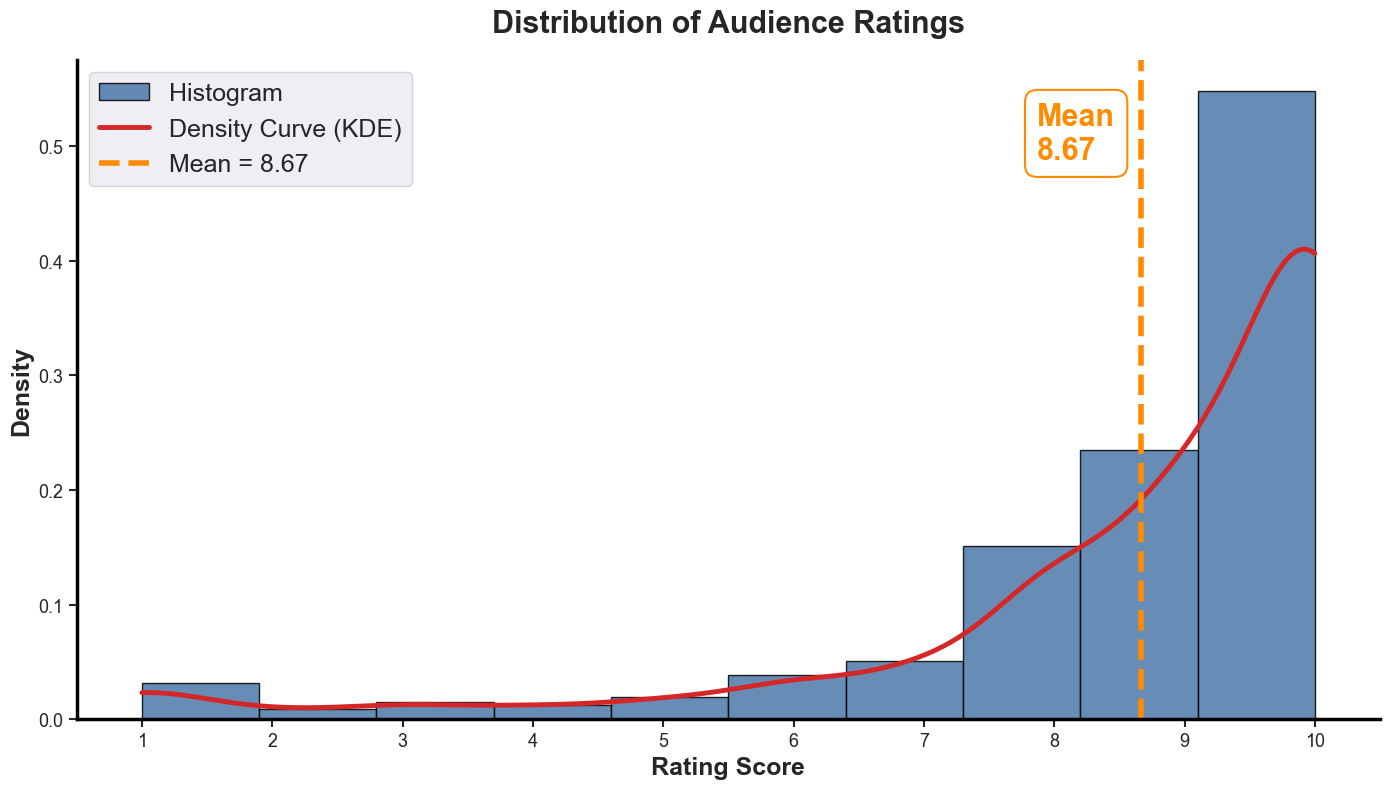

In [48]:
# Histogram and Density Plot with Mean Marker

# ==============================
# MEAN CALCULATION
# ==============================
mean_rating = df['Rating'].mean()

# ==============================
# FIGURE SETUP
# ==============================
fig, ax = plt.subplots(figsize=(14, 8))

# ==============================
# HISTOGRAM
# ==============================
ax.hist(
    df['Rating'],
    bins=10,
    density=True,
    color='#4C78A8',
    edgecolor='black',
    linewidth=1.0,
    alpha=0.85,
    label='Histogram'
)

# ==============================
# KDE CURVE
# ==============================
density = gaussian_kde(df['Rating'])

x = np.linspace(
    df['Rating'].min(),
    df['Rating'].max(),
    300
)

ax.plot(
    x,
    density(x),
    color='#D62728',
    linewidth=3.5,
    label='Density Curve (KDE)'
)

# ==============================
# MEAN MARKER
# ==============================
ax.axvline(
    mean_rating,
    color='#FF8C00',
    linestyle='--',
    linewidth=4,
    label=f'Mean = {mean_rating:.2f}'
)

# ==============================
# ANNOTATION
# ==============================
ax.text(
    mean_rating - 0.80,
    ax.get_ylim()[1] * 0.85,
    f'Mean\n{mean_rating:.2f}',
    fontsize=22,
    fontweight='bold',
    color='#FF8C00',
    bbox=dict(
        facecolor='white',
        edgecolor='#FF8C00',
        linewidth=1.5,
        boxstyle='round,pad=0.4'
    )
)

# ==============================
# TITLES & LABELS
# ==============================
ax.set_title(
    'Distribution of Audience Ratings',
    fontsize=22,
    fontweight='bold',
    pad=20
)

ax.set_xlabel(
    'Rating Score',
    fontsize=18,
    fontweight='bold'
)

ax.set_ylabel(
    'Density',
    fontsize=18,
    fontweight='bold'
)

# ==============================
# AXIS SETTINGS
# ==============================
ax.set_xlim(0.5, 10.5)
ax.set_xticks(range(1, 11))

# ==============================
# GRID
# ==============================
ax.grid(
    axis='both',
    linestyle='--',
    alpha=0.30
)

# ==============================
# LEGEND
# ==============================
ax.legend(
    fontsize=18,
    frameon=True,
    loc='upper left'
)

# ==============================
# PROFESSIONAL AXES
# ==============================
# Show X and Y axes clearly
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

ax.spines['left'].set_linewidth(2.5)
ax.spines['bottom'].set_linewidth(2.5)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# Hide unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Larger tick labels
ax.tick_params(
    axis='x',
    labelsize=13,
    width=1.5,
    length=6
)

ax.tick_params(
    axis='y',
    labelsize=13,
    width=1.5,
    length=6
)

# ==============================
# PPT STYLE
# ==============================
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

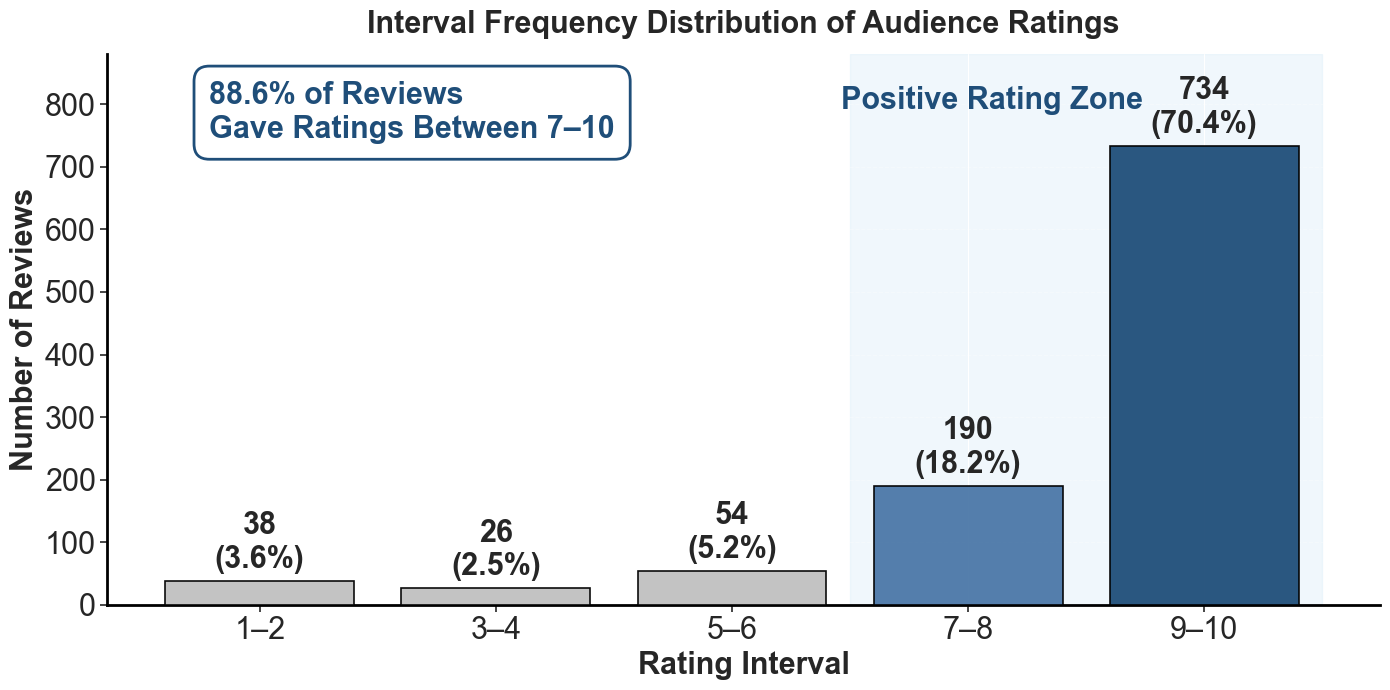

In [49]:
# Frequency Distribution Bar Chart with Highlighted Positive Zone

# ==============================
# DATA
# ==============================
intervals = freq_table['Rating Interval'].astype(str)
frequencies = freq_table['Frequency']
percentages = freq_table['Percentage']

positive_pct = (
    freq_table[
        freq_table['Rating Interval'].isin(['7-8', '9-10'])
    ]['Percentage'].sum()
)

# ==============================
# FIGURE
# ==============================
fig, ax = plt.subplots(figsize=(14, 7))

# ==============================
# COLORS
# ==============================
colors = [
    '#C0C0C0',  # 1-2
    '#C0C0C0',  # 3-4
    '#C0C0C0',  # 5-6
    '#4C78A8',  # 7-8
    '#1F4E79'   # 9-10
]

# ==============================
# HIGHLIGHT REGION
# ==============================
ax.axvspan(
    2.5,
    4.5,
    color='#D6EAF8',
    alpha=0.35,
    zorder=0
)

# ==============================
# BAR CHART
# ==============================
bars = ax.bar(
    intervals,
    frequencies,
    color=colors,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.95,
    zorder=3
)

# ==============================
# LABELS ON TOP OF BARS
# ==============================
for bar, freq, pct in zip(bars, frequencies, percentages):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        freq + max(frequencies)*0.015,
        f'{freq}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=22,
        fontweight='bold'
    )

# ==============================
# POSITIVE RECEPTION BOX
# ==============================
ax.text(
    0.08,
    0.95,
    f'88.6% of Reviews\nGave Ratings Between 7–10',
    transform=ax.transAxes,

    ha='left',
    va='top',

    fontsize=22,
    fontweight='bold',

    color='#1F4E79',

    bbox=dict(
        facecolor='white',
        edgecolor='#1F4E79',
        linewidth=2,
        boxstyle='round,pad=0.5'
    )
)

# ==============================
# HIGHLIGHT LABEL
# ==============================
ax.text(
    3.1,
    max(frequencies)*1.08,
    'Positive Rating Zone',
    ha='center',
    fontsize=22,
    fontweight='bold',
    color='#1F4E79'
)

# ==============================
# TITLE
# ==============================
ax.set_title(
    'Interval Frequency Distribution of Audience Ratings',
    fontsize=22,
    fontweight='bold',
    pad=15
)

# ==============================
# AXIS LABELS
# ==============================
ax.set_xlabel(
    'Rating Interval',
    fontsize=22,
    fontweight='bold'
)

ax.set_ylabel(
    'Number of Reviews',
    fontsize=22,
    fontweight='bold'
)

# ==============================
# Y SCALE
# ==============================
upper_limit = max(frequencies) * 1.20
ax.set_ylim(0, upper_limit)

# ==============================
# GRID
# ==============================
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.30
)

# ==============================
# AXES
# ==============================
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ==============================
# TICKS
# ==============================
ax.tick_params(
    axis='both',
    labelsize=22,
    width=1.2,
    length=5
)

# ==============================
# BACKGROUND
# ==============================
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

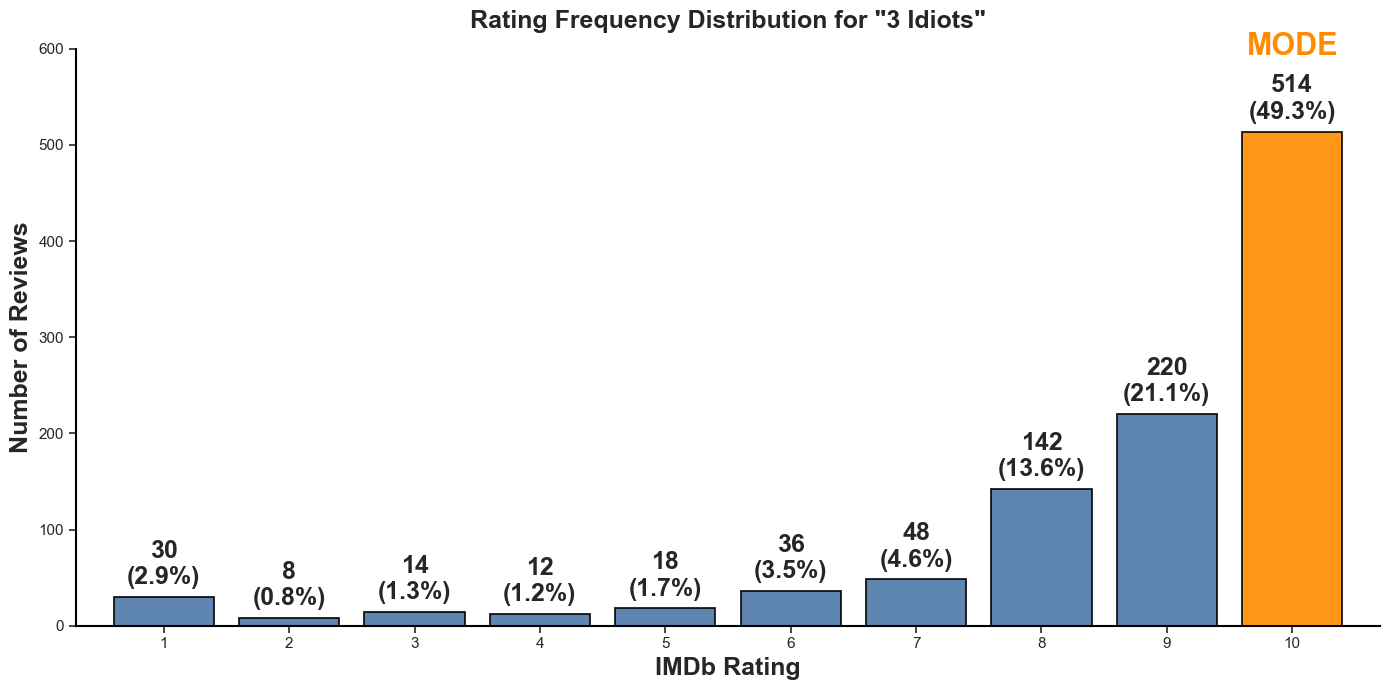

In [50]:
# Frequency Distribution Bar Chart with Mode Highlight

# ==============================
# RATING FREQUENCIES
# ==============================
rating_counts = df['Rating'].value_counts().sort_index()

ratings = rating_counts.index
frequencies = rating_counts.values

mode_rating = rating_counts.idxmax()
mode_frequency = rating_counts.max()

total_reviews = len(df)

# ==============================
# FIGURE SETUP
# ==============================
fig, ax = plt.subplots(figsize=(14, 7))

# ==============================
# COLORS
# ==============================
colors = ['#4C78A8'] * len(ratings)

# Highlight Mode Bar
for i, rating in enumerate(ratings):
    if rating == mode_rating:
        colors[i] = '#FF8C00'

# ==============================
# BAR CHART
# ==============================
bars = ax.bar(
    ratings,
    frequencies,
    color=colors,
    edgecolor='black',
    linewidth=1.3,
    alpha=0.9
)

# ==============================
# BAR LABELS
# ==============================
for bar, freq in zip(bars, frequencies):

    pct = (freq / total_reviews) * 100

    ax.text(
        bar.get_x() + bar.get_width()/2,
        freq + 8,
        f'{freq}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=18,
        fontweight='bold'
    )

# ==============================
# MODE LABEL
# ==============================
mode_bar = bars[list(ratings).index(mode_rating)]

ax.text(
    mode_bar.get_x() + mode_bar.get_width()/2,
    mode_frequency + 80,
    'MODE',
    ha='center',
    fontsize=22,
    fontweight='bold',
    color='#FF8C00'
)

# ==============================
# TITLES & LABELS
# ==============================
ax.set_title(
    'Rating Frequency Distribution for "3 Idiots"',
    fontsize=18,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'IMDb Rating',
    fontsize=18,
    fontweight='bold'
)

ax.set_ylabel(
    'Number of Reviews',
    fontsize=18,
    fontweight='bold'
)

# ==============================
# AXIS SETTINGS
# ==============================
ax.set_xticks(range(1, 11))
ax.set_xlim(0.3, 10.7)

ax.set_ylim(0, 600)
ax.set_yticks(np.arange(0, 601, 100))

# ==============================
# TICK STYLING
# ==============================
ax.tick_params(
    axis='both',
    labelsize=11,
    width=1.2,
    length=5
)

# ==============================
# GRID
# ==============================
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.30
)

# ==============================
# AXIS LINES
# ==============================
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ==============================
# PPT STYLE
# ==============================
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

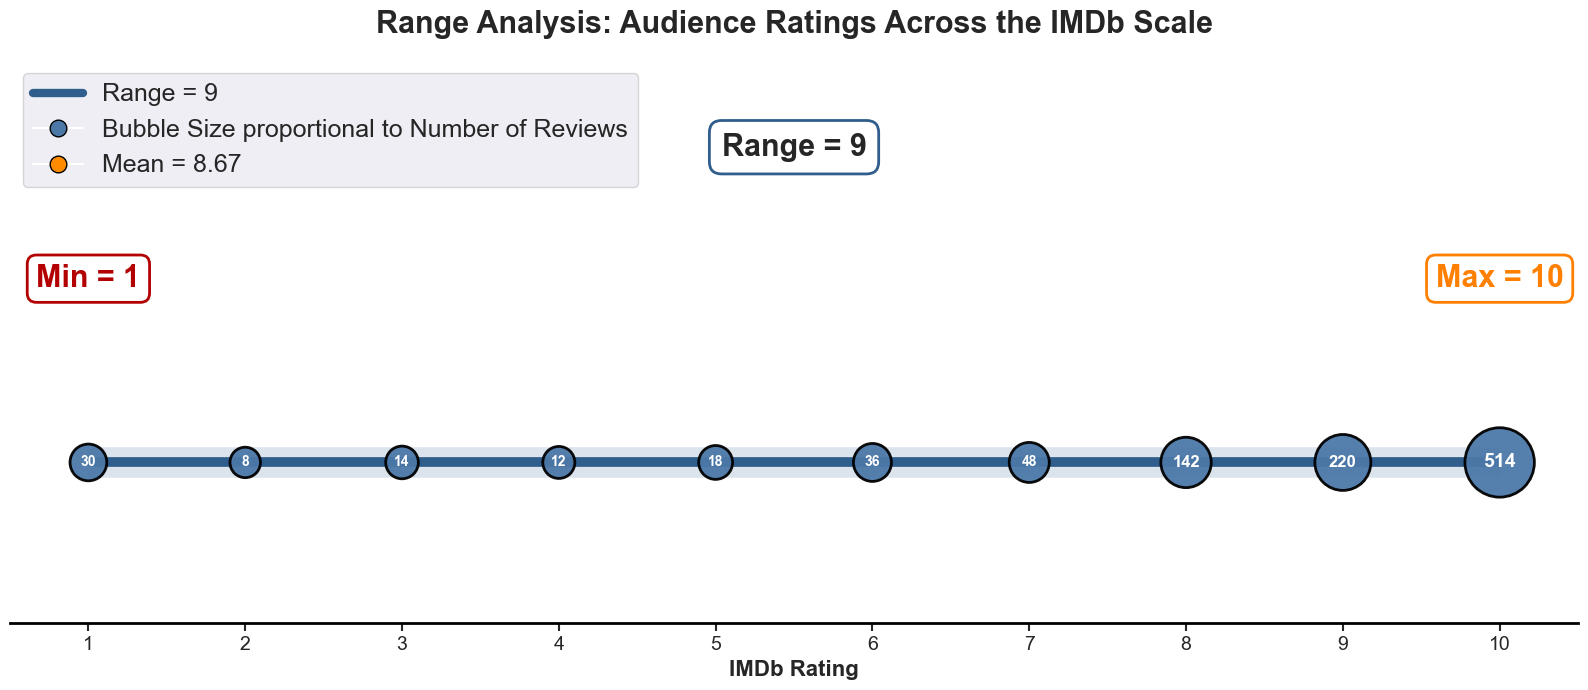

In [51]:
# Range Visualization: Min, Max, and Range of Ratings

# ==============================
# BASIC STATISTICS
# ==============================
min_rating = df['Rating'].min()
max_rating = df['Rating'].max()
mean_rating = df['Rating'].mean()

range_value = max_rating - min_rating

# ==============================
# FREQUENCY OF EACH RATING
# ==============================
rating_counts = df['Rating'].value_counts().sort_index()

ratings = rating_counts.index.values
counts = rating_counts.values

# ==============================
# BUBBLE SIZE SCALING
# ==============================
# Keeps small frequencies visible
bubble_sizes = 300 + 2200 * (counts / counts.max())**0.6

# ==============================
# FIGURE
# ==============================
fig, ax = plt.subplots(figsize=(16, 7))

# ==============================
# RANGE HIGHLIGHT BAND
# ==============================
ax.hlines(
    y=0,
    xmin=1,
    xmax=10,
    color='#4C78A8',
    linewidth=22,
    alpha=0.20,
    zorder=1
)

# Main range line
ax.hlines(
    y=0,
    xmin=1,
    xmax=10,
    color='#2F5D8C',
    linewidth=7,
    alpha=1,
    zorder=2
)

# ==============================
# BUBBLES FOR ALL RATINGS
# ==============================
ax.scatter(
    ratings,
    np.zeros(len(ratings)),
    s=bubble_sizes,
    c='#4C78A8',
    edgecolor='black',
    linewidth=2,
    alpha=0.95,
    zorder=5
)

# ==============================
# LABELS INSIDE BUBBLES
# ==============================
for rating, count in zip(ratings, counts):

    fontsize = 10

    if count > 100:
        fontsize = 12

    if count > 300:
        fontsize = 14

    ax.text(
        rating,
        0,
        f'{count}',
        ha='center',
        va='center',
        color='white',
        fontsize=fontsize,
        fontweight='bold',
        zorder=6
    )

# ==============================
# MIN LABEL
# ==============================
min_count = rating_counts.loc[min_rating]

ax.text(
    min_rating,
    0.24,

    f'Min = {int(min_rating)}',

    ha='center',
    fontsize=22,
    fontweight='bold',

    color='#B30000',

    bbox=dict(
        facecolor='white',
        edgecolor='#B30000',
        linewidth=2,
        boxstyle='round,pad=0.3'
    )
)

# ==============================
# MAX LABEL
# ==============================
max_count = rating_counts.loc[max_rating]

ax.text(
    max_rating,
    0.24,

    f'Max = {int(max_rating)}',

    ha='center',
    fontsize=22,
    fontweight='bold',

    color='#FF7F00',

    bbox=dict(
        facecolor='white',
        edgecolor='#FF7F00',
        linewidth=2,
        boxstyle='round,pad=0.3'
    )
)

# ==============================
# RANGE LABEL
# ==============================
ax.text(
    5.5,
    0.42,

    f'Range = {range_value:.0f}',

    ha='center',
    fontsize=22,
    fontweight='bold',

    bbox=dict(
        facecolor='white',
        edgecolor='#2F5D8C',
        linewidth=2,
        boxstyle='round,pad=0.4'
    )
)

# ==============================
# TITLE
# ==============================
ax.set_title(
    'Range Analysis: Audience Ratings Across the IMDb Scale',
    fontsize=22,
    fontweight='bold',
    pad=20
)

# ==============================
# AXES
# ==============================
ax.set_xlim(0.5, 10.5)
ax.set_ylim(-0.22, 0.55)

ax.set_xticks(range(1, 11))
ax.set_yticks([])

ax.set_xlabel(
    'IMDb Rating',
    fontsize=16,
    fontweight='bold'
)

# ==============================
# GRID
# ==============================
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.25
)

# ==============================
# AXIS STYLING
# ==============================
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('black')

ax.tick_params(
    axis='x',
    labelsize=14,
    width=1.5,
    length=6
)

# ==============================
# LEGEND
# ==============================
from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        color='#2F5D8C',
        lw=6,
        label=f'Range = {range_value:.0f}'
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#4C78A8',
        markeredgecolor='black',
        markersize=12,
        label='Bubble Size proportional to Number of Reviews'
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#FF8C00',
        markeredgecolor='black',
        markersize=12,
        label=f'Mean = {mean_rating:.2f}'
    )
]

ax.legend(
    handles=legend_elements,
    fontsize=18,
    loc='upper left',
    frameon=True
)

# ==============================
# BACKGROUND
# ==============================
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

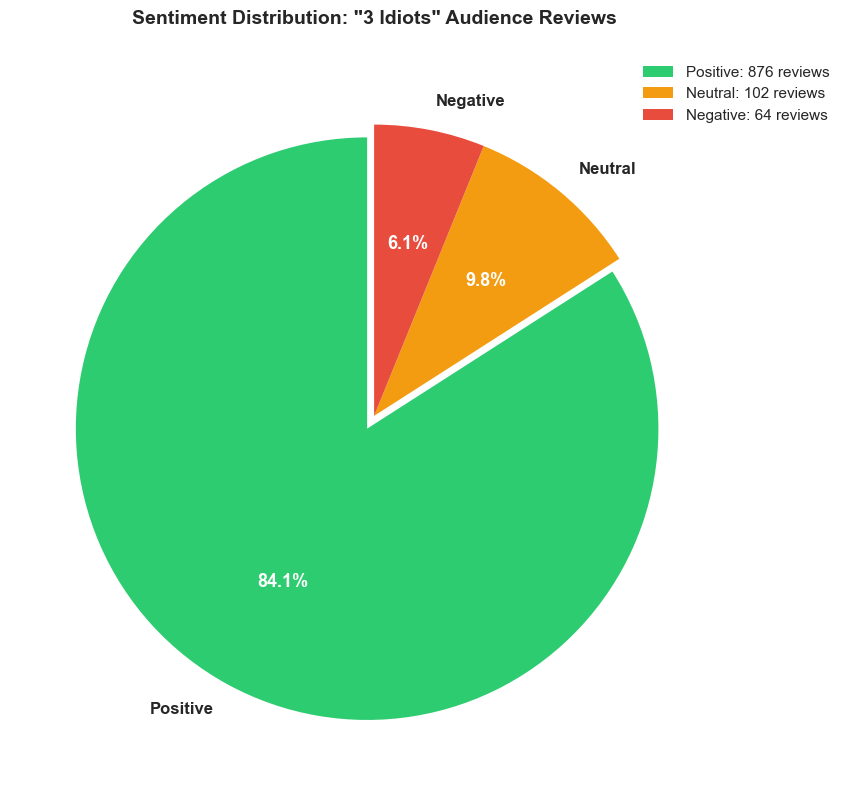

In [52]:
# Pie Chart: Sentiment Proportions of Audience Reviews

# Calculate sentiment proportions
sentiment_data = df['Review Type'].value_counts()
sentiment_order = ['Positive', 'Neutral', 'Negative']
sentiment_values = [sentiment_data.get(s, 0) for s in sentiment_order]
sentiment_pct = [val / sum(sentiment_values) * 100 for val in sentiment_values]

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
explode = (0.05, 0, 0)  # Slightly separate the Positive slice

wedges, texts, autotexts = ax.pie(sentiment_values, labels=sentiment_order, autopct='%1.1f%%',
                                    colors=colors, explode=explode, startangle=90,
                                    textprops={'fontsize': 12, 'fontweight': 'bold'})

# Style the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')

# Add title
ax.set_title('Sentiment Distribution: "3 Idiots" Audience Reviews', 
             fontsize=14, fontweight='bold', pad=20)

# Add legend with counts
legend_labels = [f'{sent}: {val} reviews' for sent, val in zip(sentiment_order, sentiment_values)]
ax.legend(legend_labels, loc='upper left', bbox_to_anchor=(0.85, 0, 0.2, 1), fontsize=11)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

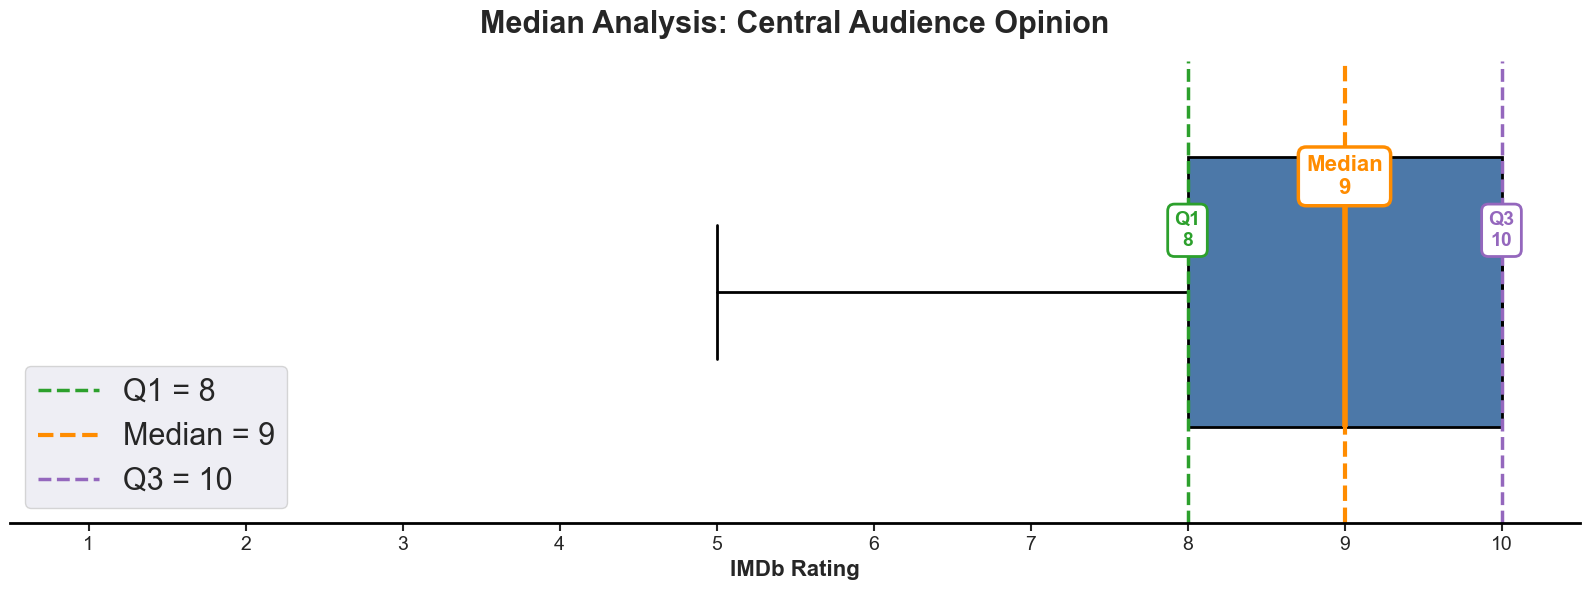

In [53]:
# Box Plot: Median, Quartiles, and Outliers of Ratings

# ==============================
# STATISTICS
# ==============================
median_rating = df['Rating'].median()
q1 = df['Rating'].quantile(0.25)
q3 = df['Rating'].quantile(0.75)

# ==============================
# FIGURE
# ==============================
fig, ax = plt.subplots(figsize=(16, 6))

# ==============================
# HORIZONTAL BOX PLOT
# ==============================
ax.boxplot(
    df['Rating'],
    vert=False,
    patch_artist=True,
    widths=0.35,

    boxprops=dict(
        facecolor='#4C78A8',
        edgecolor='black',
        linewidth=2
    ),

    medianprops=dict(
        color='#FF8C00',
        linewidth=4
    ),

    whiskerprops=dict(
        color='black',
        linewidth=2
    ),

    capprops=dict(
        color='black',
        linewidth=2
    ),

    flierprops=dict(
        marker='',
        markersize=0
    )
)

# ==============================
# QUARTILE REFERENCE LINES
# ==============================
ax.axvline(
    q1,
    color='#2CA02C',
    linestyle='--',
    linewidth=2.5
)

ax.axvline(
    median_rating,
    color='#FF8C00',
    linestyle='--',
    linewidth=3
)

ax.axvline(
    q3,
    color='#9467BD',
    linestyle='--',
    linewidth=2.5
)

# ==============================
# Q1 LABEL
# ==============================
ax.text(
    q1,
    1.08,

    f'Q1\n{q1:.0f}',

    ha='center',
    va='center',

    fontsize=14,
    fontweight='bold',
    color='#2CA02C',

    bbox=dict(
        facecolor='white',
        edgecolor='#2CA02C',
        linewidth=2,
        boxstyle='round,pad=0.35'
    )
)

# ==============================
# MEDIAN LABEL
# ==============================
ax.text(
    median_rating,
    1.15,

    f'Median\n{median_rating:.0f}',

    ha='center',
    va='center',

    fontsize=16,
    fontweight='bold',
    color='#FF8C00',

    bbox=dict(
        facecolor='white',
        edgecolor='#FF8C00',
        linewidth=2.5,
        boxstyle='round,pad=0.35'
    )
)

# ==============================
# Q3 LABEL
# ==============================
ax.text(
    q3,
    1.08,

    f'Q3\n{q3:.0f}',

    ha='center',
    va='center',

    fontsize=14,
    fontweight='bold',
    color='#9467BD',

    bbox=dict(
        facecolor='white',
        edgecolor='#9467BD',
        linewidth=2,
        boxstyle='round,pad=0.35'
    )
)

# ==============================
# TITLE
# ==============================
ax.set_title(
    'Median Analysis: Central Audience Opinion',
    fontsize=22,
    fontweight='bold',
    pad=20
)

# ==============================
# X AXIS
# ==============================
ax.set_xlim(0.5, 10.5)
ax.set_xticks(range(1, 11))

ax.set_xlabel(
    'IMDb Rating',
    fontsize=16,
    fontweight='bold'
)

# ==============================
# Y AXIS
# ==============================
ax.set_yticks([])

# Extra space for labels
ax.set_ylim(0.70, 1.30)

# ==============================
# GRID
# ==============================
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.30
)

# ==============================
# AXIS STYLING
# ==============================
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('black')

ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ==============================
# TICKS
# ==============================
ax.tick_params(
    axis='x',
    labelsize=14,
    width=1.5,
    length=6
)

# ==============================
# LEGEND
# ==============================
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='#2CA02C', lw=2.5, linestyle='--', label=f'Q1 = {q1:.0f}'),
    Line2D([0], [0], color='#FF8C00', lw=3, linestyle='--', label=f'Median = {median_rating:.0f}'),
    Line2D([0], [0], color='#9467BD', lw=2.5, linestyle='--', label=f'Q3 = {q3:.0f}')
]

ax.legend(
    handles=legend_elements,
    fontsize=22,
    loc='lower left',
    frameon=True
)

# ==============================
# PPT STYLE
# ==============================
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

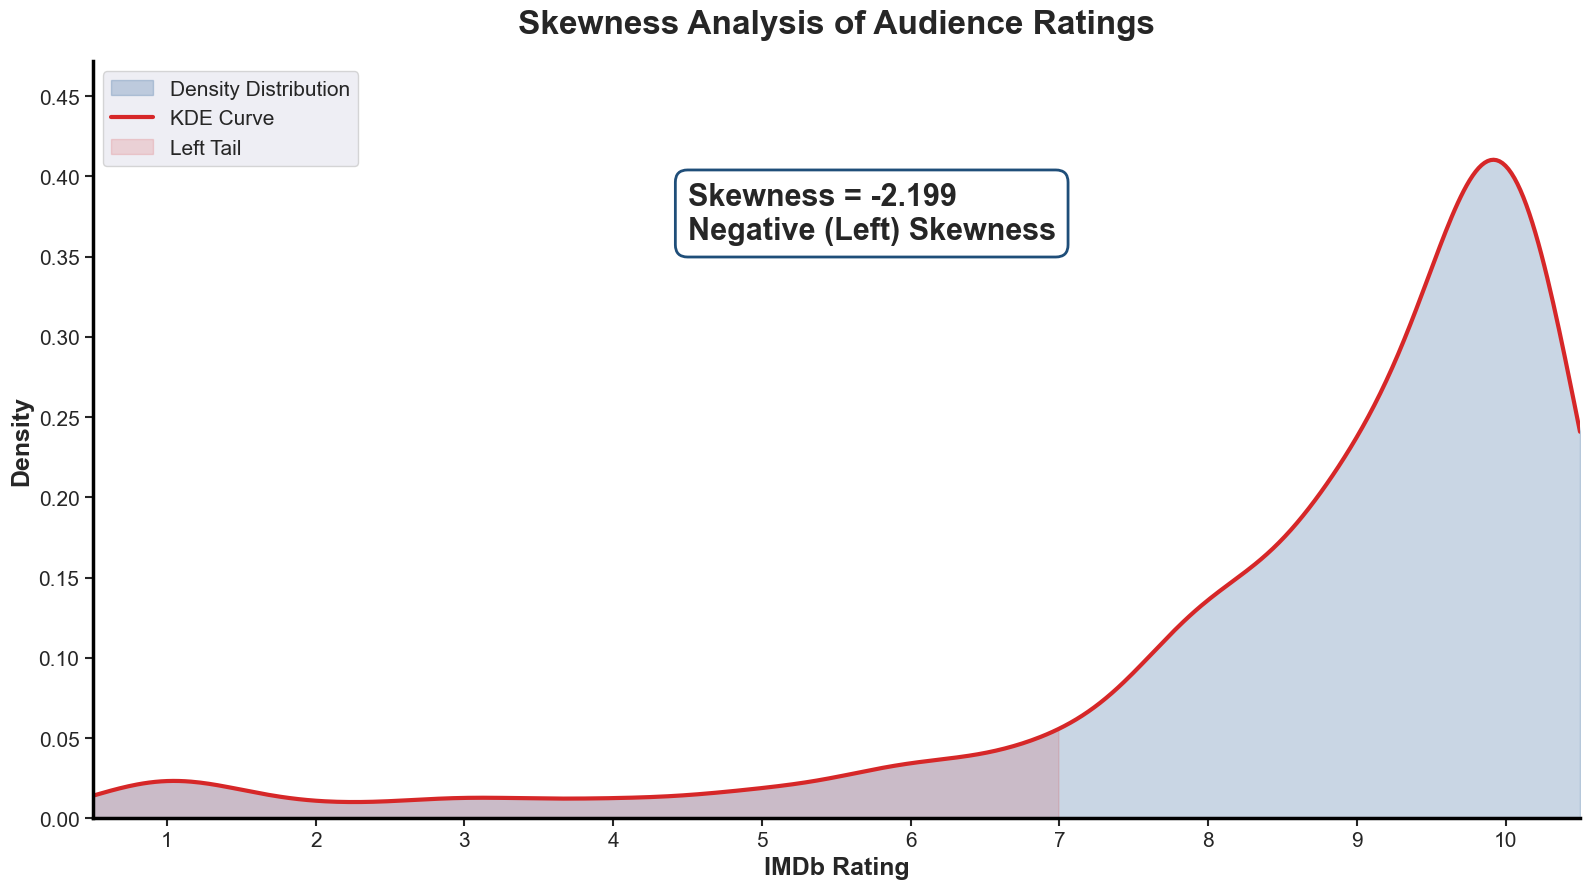

In [54]:
# KDE Plot: Skewness Visualization of Audience Ratings

# ==============================
# STATISTICS
# ==============================
mean_rating = df['Rating'].mean()
median_rating = df['Rating'].median()

density = gaussian_kde(df['Rating'])

x = np.linspace(0.5, 10.5, 500)
y = density(x)

# ==============================
# FIGURE
# ==============================
fig, ax = plt.subplots(figsize=(16, 9))

# Force white background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ==============================
# DENSITY AREA
# ==============================
ax.fill_between(
    x,
    y,
    color='#4C78A8',
    alpha=0.30,
    label='Density Distribution'
)

# KDE Curve
ax.plot(
    x,
    y,
    color='#D62728',
    linewidth=3,
    label='KDE Curve'
)

# ==============================
# LEFT TAIL HIGHLIGHT
# ==============================
tail_mask = x <= 7

ax.fill_between(
    x[tail_mask],
    y[tail_mask],
    color='#D62728',
    alpha=0.15,
    label='Left Tail'
)

# ==============================
# SKEWNESS BOX
# ==============================
ax.text(
    4.5,
    y.max()*0.88,

    f'Skewness = {skewness:.3f}\nNegative (Left) Skewness',

    fontsize=22,
    fontweight='bold',

    bbox=dict(
        facecolor='white',
        edgecolor='#1F4E79',
        linewidth=2,
        boxstyle='round,pad=0.4'
    )
)

# ==============================
# TITLE
# ==============================
ax.set_title(
    'Skewness Analysis of Audience Ratings',
    fontsize=24,
    fontweight='bold',
    pad=20
)

# ==============================
# AXIS LABELS
# ==============================
ax.set_xlabel(
    'IMDb Rating',
    fontsize=18,
    fontweight='bold'
)

ax.set_ylabel(
    'Density',
    fontsize=18,
    fontweight='bold'
)

# ==============================
# X AXIS
# ==============================
ax.set_xlim(0.5, 10.5)
ax.set_xticks(range(1, 11))

# ==============================
# Y AXIS
# ==============================
ax.set_ylim(0, y.max() * 1.15)

y_ticks = np.arange(
    0,
    round(y.max() * 1.2, 2),
    0.05
)

ax.set_yticks(y_ticks)

# ==============================
# LIGHT GRID
# ==============================
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.20
)

# ==============================
# PROFESSIONAL AXES
# ==============================
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

ax.spines['left'].set_linewidth(2.5)
ax.spines['bottom'].set_linewidth(2.5)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ==============================
# TICKS
# ==============================
ax.tick_params(
    axis='x',
    labelsize=15,
    width=1.5,
    length=6
)

ax.tick_params(
    axis='y',
    labelsize=15,
    width=1.5,
    length=6
)

# ==============================
# LEGEND
# ==============================
ax.legend(
    fontsize=15,
    loc='upper left',
    frameon=True
)

plt.tight_layout()
plt.show()

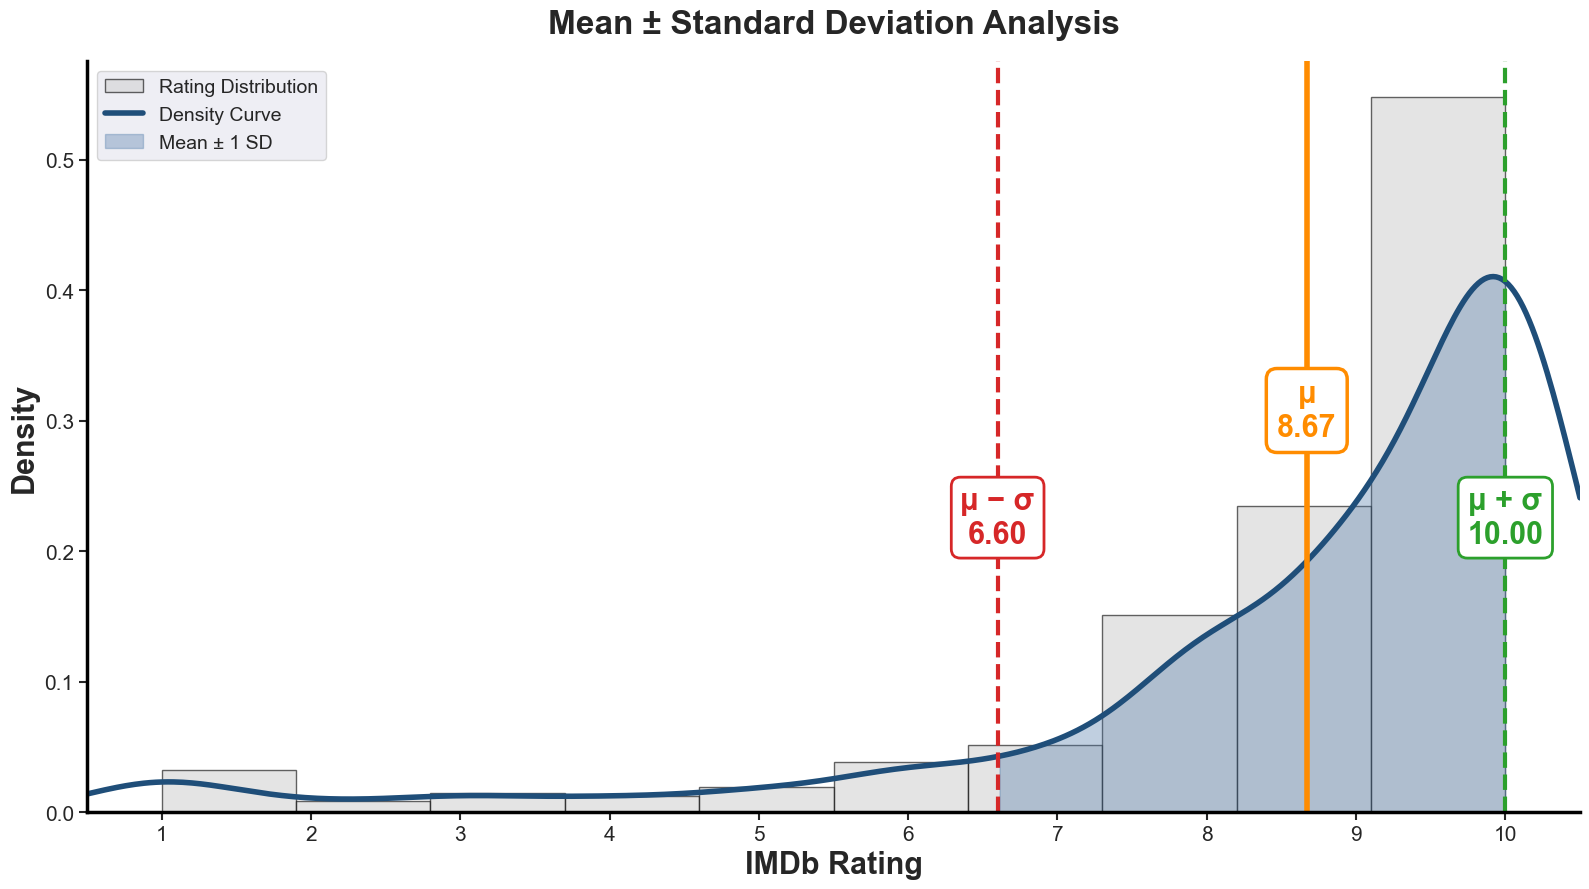

In [55]:
# KDE Plot: Skewness Visualization of Audience Ratings

# ==============================
# STATISTICS
# ==============================
mean_rating = df['Rating'].mean()
std_rating = df['Rating'].std()

lower = mean_rating - std_rating
upper = min(mean_rating + std_rating, 10)

# ==============================
# FIGURE
# ==============================
fig, ax = plt.subplots(figsize=(16, 9))

# ==============================
# HISTOGRAM
# ==============================
ax.hist(
    df['Rating'],
    bins=10,
    density=True,
    color='lightgray',
    edgecolor='black',
    linewidth=1,
    alpha=0.6,
    label='Rating Distribution'
)

# ==============================
# KDE CURVE
# ==============================
density = gaussian_kde(df['Rating'])

x = np.linspace(0.5, 10.5, 500)
y = density(x)

ax.plot(
    x,
    y,
    color='#1F4E79',
    linewidth=4,
    label='Density Curve'
)

# ==============================
# SHADED μ ± σ REGION
# ==============================
mask = (x >= lower) & (x <= upper)

ax.fill_between(
    x[mask],
    y[mask],
    color='#4C78A8',
    alpha=0.35,
    label='Mean ± 1 SD'
)

# ==============================
# MEAN - SD LINE
# ==============================
ax.axvline(
    lower,
    color='#D62728',
    linewidth=3,
    linestyle='--'
)


# ==============================
# MEAN LINE
# ==============================
ax.axvline(
    mean_rating,
    color='#FF8C00',
    linewidth=4
)

# ==============================
# MEAN + SD LINE
# ==============================
ax.axvline(
    upper,
    color='#2CA02C',
    linewidth=3,
    linestyle='--'
)

# ==============================
# MEAN - SD LABEL
# ==============================
ax.text(
    lower,
    y.max()*0.55,
    f'μ − σ\n{lower:.2f}',
    ha='center',
    va='center',

    fontsize=22,
    fontweight='bold',
    color='#D62728',

    bbox=dict(
        facecolor='white',
        edgecolor='#D62728',
        linewidth=2,
        boxstyle='round,pad=0.3'
    )
)

# ==============================
# MEAN LABEL
# ==============================
ax.text(
    mean_rating,
    y.max()*0.75,
    f'μ\n{mean_rating:.2f}',
    ha='center',
    va='center',

    fontsize=22,
    fontweight='bold',
    color='#FF8C00',

    bbox=dict(
        facecolor='white',
        edgecolor='#FF8C00',
        linewidth=2.5,
        boxstyle='round,pad=0.35'
    )
)

# ==============================
# MEAN + SD LABEL
# ==============================
ax.text(
    upper,
    y.max()*0.55,
    f'μ + σ\n{upper:.2f}',
    ha='center',
    va='center',

    fontsize=22,
    fontweight='bold',
    color='#2CA02C',

    bbox=dict(
        facecolor='white',
        edgecolor='#2CA02C',
        linewidth=2,
        boxstyle='round,pad=0.3'
    )
)

# ==============================
# TITLE
# ==============================
ax.set_title(
    'Mean ± Standard Deviation Analysis',
    fontsize=24,
    fontweight='bold',
    pad=20
)

# ==============================
# AXIS LABELS
# ==============================
ax.set_xlabel(
    'IMDb Rating',
    fontsize=22,
    fontweight='bold'
)

ax.set_ylabel(
    'Density',
    fontsize=22,
    fontweight='bold'
)

# ==============================
# AXIS SETTINGS
# ==============================
ax.set_xlim(0.5, 10.5)
ax.set_xticks(range(1, 11))

# ==============================
# GRID
# ==============================
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.30
)

# ==============================
# PROFESSIONAL AXES
# ==============================
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

ax.spines['left'].set_linewidth(2.5)
ax.spines['bottom'].set_linewidth(2.5)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ==============================
# TICKS
# ==============================
ax.tick_params(
    axis='x',
    labelsize=15,
    width=1.5,
    length=6
)

ax.tick_params(
    axis='y',
    labelsize=15,
    width=1.5,
    length=6
)

# ==============================
# LEGEND
# ==============================
ax.legend(
    fontsize=14,
    frameon=True,
    loc='upper left'
)

# ==============================
# BACKGROUND
# ==============================
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

## Module 5: ADVANCED MODULE 2 – AUDIENCE EFFORT DYNAMICS (TEXT LENGTH VS. NUMERICAL RATING)

### The Psychology of Review Effort

A fundamental insight in audience behavior research: **the length of a review is inversely related to the emotional intensity of the rating**. This reflects basic human psychology:

1. **Extreme Ratings ($1$ and $10$)**: Represent unambiguous emotional responses ("I hated it" or "I loved it"). These are high-conviction statements that require minimal explanation—hence shorter, punchier text.

2. **Moderate Ratings ($3$-$8$)**: Represent nuanced, mixed, or complex opinions ("It was good but had flaws"). These require detailed exposition to justify the moderate position—hence longer, more analytical text.

### Research Questions

- How does average review length vary across the 1-10 rating scale?
- Do extreme ratings (1, 10) show lower text effort than moderate ratings (3-8)?
- What is the global average review length, and which rating buckets deviate most?

### Mathematical Framework

For each numerical rating $r \in \{1, 2, \ldots, 10\}$, we compute the mean text length:

$$\bar{L}(r) = \frac{1}{|S_r|}\sum_{i \in S_r} \text{length}(\text{text}_i)$$

where $S_r$ is the set of reviews with rating $r$, and $\text{length}(\text{text}_i)$ is the character count of review $i$.

We compare these per-rating averages against the global average:

$$\bar{L}_{\text{global}} = \frac{1}{n}\sum_{i=1}^{n} \text{length}(\text{text}_i)$$

In [56]:
# =============================================================================
# ADVANCED MODULE 2
# AUDIENCE EFFORT DYNAMICS
# =============================================================================

# Character Count
df['Text_Length'] = df['Review Text'].astype(str).str.len()

# Word Count
df['Word_Count'] = df['Review Text'].astype(str).str.split().str.len()

# Sentence Count
df['Sentence_Count'] = (
    df['Review Text']
    .astype(str)
    .str.count(r'[.!?]') + 1
)

print("="*80)
print("REVIEW LENGTH STATISTICS")
print("="*80)

global_mean_length = df['Text_Length'].mean()

length_groups = (
    df.groupby('Rating')
      .agg(
          avg_length=('Text_Length', 'mean'),
          median_length=('Text_Length', 'median'),
          avg_word_count=('Word_Count', 'mean'),
          avg_sentence_count=('Sentence_Count', 'mean'),
          std_length=('Text_Length', 'std'),
          review_count=('Text_Length', 'count')
      )
      .reset_index()
)

display(length_groups.round(2))

REVIEW LENGTH STATISTICS


,Rating,avg_length,median_length,avg_word_count,avg_sentence_count,std_length,review_count
0,1,497.10,589.0,90.30,7.43,347.98,30
1,2,405.38,267.0,71.12,9.12,448.25,8
2,3,866.86,706.0,152.21,11.86,1108.77,14
3,4,616.92,110.0,111.42,8.75,856.37,12
4,5,910.22,670.0,162.94,13.00,939.94,18
5,6,905.17,525.0,161.69,9.36,1239.12,36
6,7,889.25,672.0,155.77,10.92,1014.04,48
7,8,986.18,653.0,169.92,12.77,1151.26,142
8,9,673.95,471.5,118.52,9.30,833.20,220
9,10,666.70,363.5,116.64,9.79,897.41,514


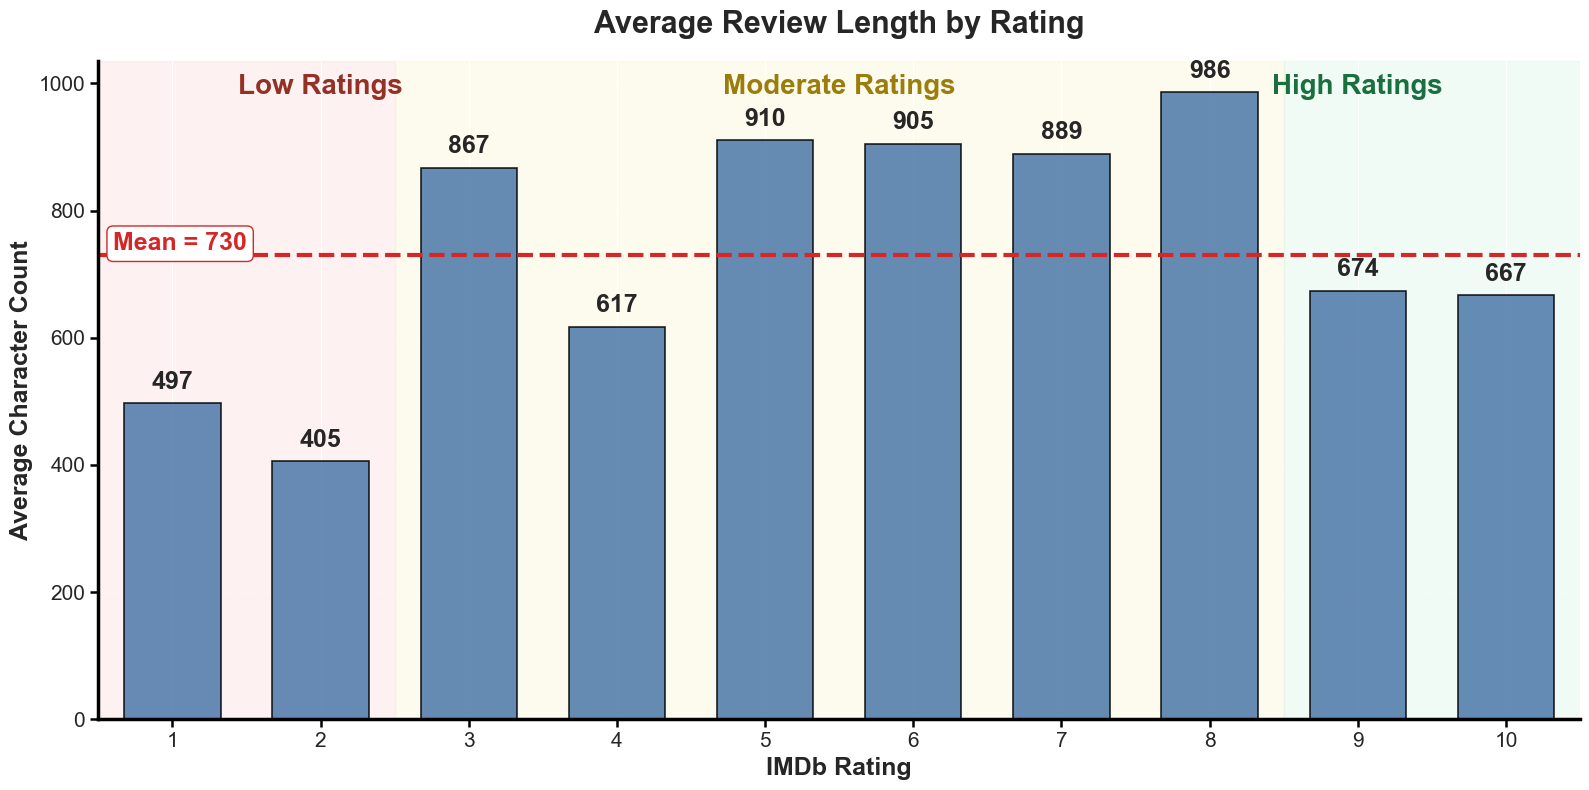

In [57]:
# ==========================================
# DATA
# ==========================================
ratings = length_groups['Rating'].values
avg_lengths = length_groups['avg_length'].values

# ==========================================
# FIGURE
# ==========================================
fig, ax = plt.subplots(figsize=(16, 8))

fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ==========================================
# BACKGROUND ZONES
# ==========================================

# Low ratings zone
ax.axvspan(
    0.5, 2.5,
    color='#FADBD8',
    alpha=0.35,
    zorder=0
)

# Moderate ratings zone
ax.axvspan(
    2.5, 8.5,
    color='#FCF3CF',
    alpha=0.35,
    zorder=0
)

# High ratings zone
ax.axvspan(
    8.5, 10.5,
    color='#D5F5E3',
    alpha=0.35,
    zorder=0
)

# ==========================================
# BAR CHART
# ==========================================
bars = ax.bar(
    ratings,
    avg_lengths,

    width=0.65,

    color='#4C78A8',
    edgecolor='black',
    linewidth=1.2,

    alpha=0.85,

    label='Average Review Length'
)

# ==========================================
# GLOBAL AVERAGE LINE
# ==========================================
ax.axhline(
    global_mean_length,
    color='#D62728',
    linestyle='--',
    linewidth=3,
    label=f'Overall Average = {global_mean_length:.0f}'
)

# ==========================================
# MEAN LABEL ON Y-AXIS
# ==========================================
ax.text(
    0.6,                          # just inside left side
    global_mean_length,

    f'Mean = {global_mean_length:.0f}',

    color='#D62728',
    fontsize=18,
    fontweight='bold',

    ha='left',
    va='bottom',

    bbox=dict(
        facecolor='white',
        edgecolor='#D62728',
        boxstyle='round,pad=0.25'
    )
)

# ==========================================
# DATA LABELS
# ==========================================
for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 15,

        f'{height:.0f}',

        ha='center',
        va='bottom',

        fontsize=18,
        fontweight='bold'
    )

# ==========================================
# ZONE LABELS
# ==========================================
ax.text(
    2,
    ax.get_ylim()[1]*0.95,

    'Low Ratings',
    ha='center',

    fontsize=20,
    fontweight='bold',
    color='#943126'
)

ax.text(
    5.5,
    ax.get_ylim()[1]*0.95,

    'Moderate Ratings',
    ha='center',

    fontsize=20,
    fontweight='bold',
    color='#9A7D0A'
)

ax.text(
    9,
    ax.get_ylim()[1]*0.95,

    'High Ratings',
    ha='center',

    fontsize=20,
    fontweight='bold',
    color='#196F3D'
)

# ==========================================
# TITLE
# ==========================================
ax.set_title(
    'Average Review Length by Rating',
    fontsize=22,
    fontweight='bold',
    pad=20
)

# ==========================================
# AXIS LABELS
# ==========================================
ax.set_xlabel(
    'IMDb Rating',
    fontsize=18,
    fontweight='bold'
)

ax.set_ylabel(
    'Average Character Count',
    fontsize=18,
    fontweight='bold'
)

# ==========================================
# AXIS SETTINGS
# ==========================================
ax.set_xticks(range(1, 11))

# ==========================================
# GRID
# ==========================================
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

# ==========================================
# PROFESSIONAL AXES
# ==========================================
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

ax.spines['left'].set_linewidth(2.5)
ax.spines['bottom'].set_linewidth(2.5)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Force visible axis limits
ax.set_xlim(0.5, 10.5)

ax.set_ylim(
    0,
    max(avg_lengths) * 1.05
)

# ==========================================
# TICKS
# ==========================================
ax.tick_params(
    axis='x',
    labelsize=15,
    width=1.8,
    length=6,
    color='black'
)

ax.tick_params(
    axis='y',
    labelsize=15,
    width=1.8,
    length=6,
    color='black'
)

plt.tight_layout()
plt.show()